# Project 03 — Revenue Decomposition
Dataset: Online Retail II (Kaggle)
Goal: Decompose revenue into Active Customers × Orders per Customer × AOV (monthly).

### 1 — Setup

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2 — Load & standardise schema

In [145]:
df = pd.read_csv("online_retail_II.csv", sep=";")

df = df.rename(columns={"Customer ID": "CustomerID"})

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%y %H:%M",
    errors="coerce"
)

df.shape, df.columns

((541910, 8),
 Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
        'Price', 'CustomerID', 'Country'],
       dtype='str'))

## 3. Clean transactions + construct Month & Revenue

We keep only mechanically valid sales (valid customer, positive quantity, positive price). Compute revenue and month index.


In [146]:
clean = (
    df
    .dropna(subset=["CustomerID", "InvoiceDate"])
    .query("Quantity > 0 and Price > 0")
    .assign(
        CustomerID=lambda x: x["CustomerID"].astype(int),
        Revenue=lambda x: x["Quantity"] * x["Price"],
        Month=lambda x: x["InvoiceDate"].dt.to_period("M")
    )
)

clean["Month"].nunique(), clean["Month"].min(), clean["Month"].max()


(13, Period('2010-12', 'M'), Period('2011-12', 'M'))

## 4 — Aggregate monthly & computer revenue drivers

In [147]:
monthly = (
    clean
    .groupby("Month")
    .agg(
        Revenue=("Revenue", "sum"),
        ActiveCustomers=("CustomerID", "nunique"),
        Orders=("Invoice", "nunique")
    )
    .reset_index()
    .sort_values("Month")
    .assign(
        OrdersPerCustomer=lambda x: x["Orders"] / x["ActiveCustomers"],
        AOV=lambda x: x["Revenue"] / x["Orders"]
    )
)

monthly.head()


,Month,Revenue,ActiveCustomers,Orders,OrdersPerCustomer,AOV
0,2010-12,572713.89,885,1400,1.581921,409.081350
1,2011-01,569445.04,741,987,1.331984,576.945329
2,2011-02,447137.35,758,997,1.315303,448.482798
3,2011-03,595500.76,974,1321,1.356263,450.795428
4,2011-04,469201.36,856,1149,1.342290,408.356275


### 5 — Validate the revenue identity

As a consistency check, we reconstruct revenue from its components
and compare it to observed revenue.

In [148]:
monthly = monthly.assign(
    ReconstructedRevenue=lambda x: x["ActiveCustomers"] * x["OrdersPerCustomer"] * x["AOV"]
)

relative_error = (
    (monthly["Revenue"] - monthly["ReconstructedRevenue"]).abs() / monthly["Revenue"]
).max()

relative_error


np.float64(1.1232429358228416e-16)

Small numerical differences are due to floating-point arithmetic and are not analytically meaningful.

### 6 — Resulting dataset
At this point, we have a monthly dataset containing:
- Revenue
- Active customers
- Orders
- Orders per customer
- Average order value (AOV)

This table fully decomposes revenue into its mechanical drivers
and forms the basis for interpretation.


In [149]:
monthly.head()

,Month,Revenue,ActiveCustomers,Orders,OrdersPerCustomer,AOV,ReconstructedRevenue
0,2010-12,572713.89,885,1400,1.581921,409.081350,572713.89
1,2011-01,569445.04,741,987,1.331984,576.945329,569445.04
2,2011-02,447137.35,758,997,1.315303,448.482798,447137.35
3,2011-03,595500.76,974,1321,1.356263,450.795428,595500.76
4,2011-04,469201.36,856,1149,1.342290,408.356275,469201.36


### 7 — Visual inspection of revenue drivers

We compare revenue against its mechanical components to understand:
- which drivers trend over time
- which are stable
- which are volatile or noisy


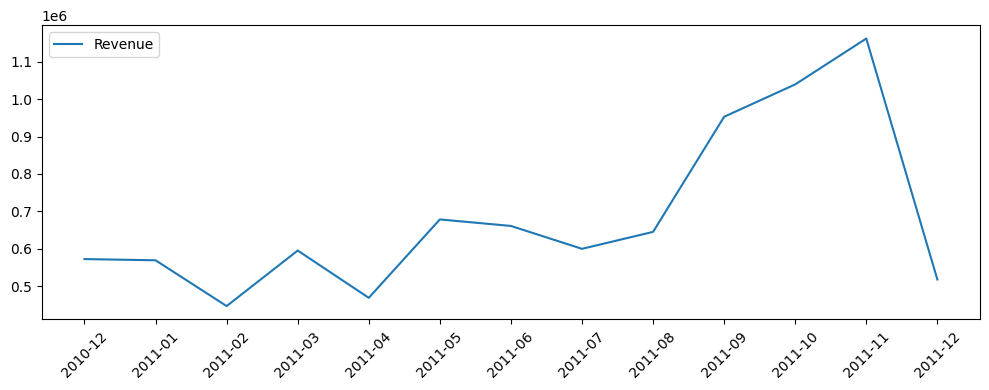

In [150]:
plt.figure(figsize=(10, 4))
plt.plot(monthly["Month"].astype(str), monthly["Revenue"], label="Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

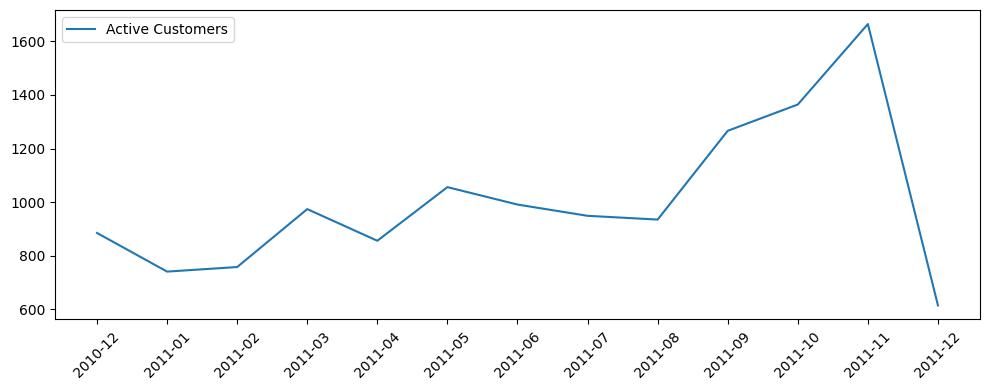

In [151]:
plt.figure(figsize=(10, 4))
plt.plot(monthly["Month"].astype(str), monthly["ActiveCustomers"], label="Active Customers")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

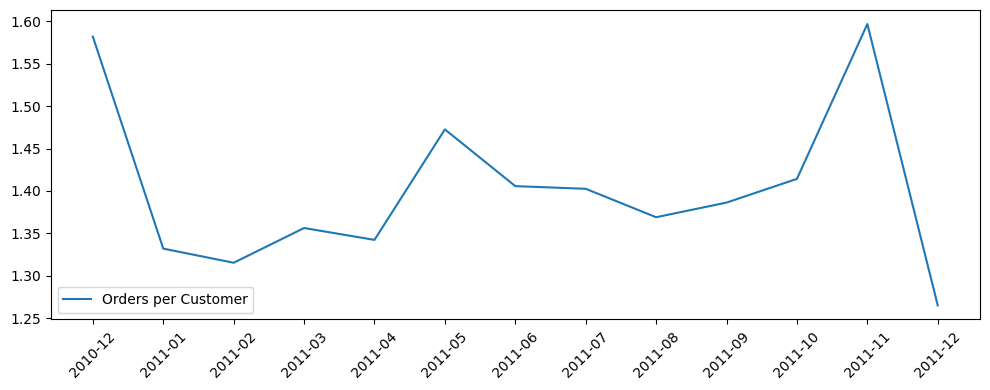

In [152]:
plt.figure(figsize=(10, 4))
plt.plot(monthly["Month"].astype(str), monthly["OrdersPerCustomer"], label="Orders per Customer")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

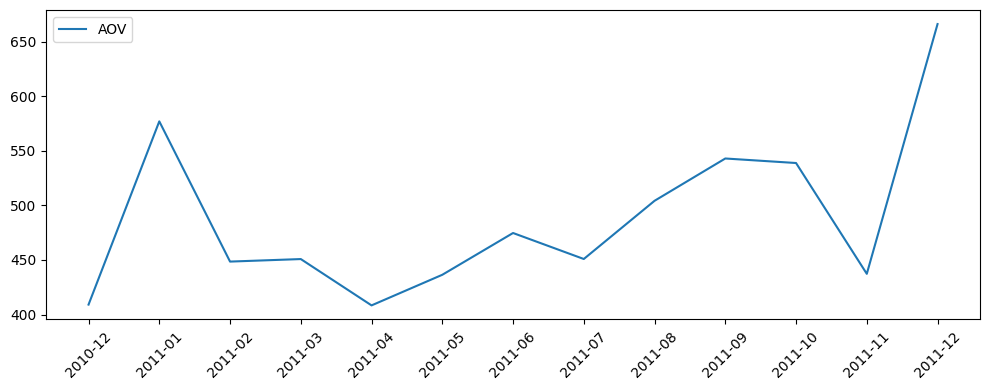

In [153]:
plt.figure(figsize=(10, 4))
plt.plot(monthly["Month"].astype(str), monthly["AOV"], label="AOV")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

### 8 — Interpreting the drivers

Revenue co-moves strongly with Active Customers, indicating customer participation is the dominant mechanical driver. Orders per Customer tends to rise during peak periods and reinforces the revenue pattern rather than independently driving it. AOV shows pronounced seasonality and often moves counter to volume (e.g., lower AOV in high-volume months and higher AOV in lower-activity months), suggesting mix or pricing effects. This decomposition is structural and descriptive: it shows what must have changed mechanically for revenue to change, but it does not attribute causality.